# 10 — Event Study: CG Filing Dates

Short-window abnormal-return event study around CG filing dates. Independent of `06`–`09`'s
panel/portfolio work — this asks a narrower question: does the market move around the
*disclosure* of a firm's governance report, and does the size of that move relate to the
CG score being disclosed?

**Design decisions (confirmed):**
- **Events**: every quarterly CG filing (all 4 quarters, not just Q4) for the ~247 firms in
  `matched_companies.xlsx` — maximizes power, matches the spec's "CG_score is the score for
  the filing quarter."
- **Estimation window**: (−250, −20) trading days before the filing date. Market model:
  `r_it = α + β'F_t + ε_it` on FF5+MOM factors (reconstructed to daily from
  `ff5mom_factors_monthly.csv`, same method as `08_ff5_regression.ipynb`).
- **Event windows**: (−1,+1), (−3,+3), (−5,+5), (−10,+10), (0,+5) trading days.
- **Overlapping filings**: primary results include *all* events; a separate robustness table
  excludes the second of any pair of filings (same firm) within 20 trading days of each other.
- **Multiple testing**: Romano-Wolf step-down, cluster (firm) bootstrap, B=2,000 replications,
  applied across the (sub-index × window) = 30-test family.

**Data constraint found empirically (not a design choice):** `ff5mom_factors_monthly.csv`
only covers 2022-07 through 2026-04. A (−250,−20 td) estimation window is therefore only
*fully* covered by factor data for filings from **2023-07-06** onward — earlier filings are
dropped from the estimation sample, not silently included with a partial window. This caps
the usable event sample at roughly FY24–FY26 filings (~2,500 events after all availability
filters), reported explicitly in the funnel below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

BASE = Path.cwd()
RAW  = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

RF_ANNUAL, RF_DAILY = 0.065, 0.065 / 252
FACTOR_COLS = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
EST_START, EST_END = -250, -20
EVENT_WINDOWS = {'m1p1': (-1, 1), 'm3p3': (-3, 3), 'm5p5': (-5, 5),
                  'm10p10': (-10, 10), '0p5': (0, 5)}
MIN_EST_OBS = 150          # minimum non-missing days required within the estimation window
OVERLAP_TD = 20            # trading days: a second filing within this gap is flagged as overlapping
RW_B = 2000                # Romano-Wolf bootstrap replications
CG_CATS = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']

print('Event windows:', EVENT_WINDOWS)
print(f'Estimation window: ({EST_START}, {EST_END}) trading days  |  MIN_EST_OBS={MIN_EST_OBS}')

Event windows: {'m1p1': (-1, 1), 'm3p3': (-3, 3), 'm5p5': (-5, 5), 'm10p10': (-10, 10), '0p5': (0, 5)}
Estimation window: (-250, -20) trading days  |  MIN_EST_OBS=150


## 1 — Event universe

Every quarterly CG filing for firms in the matched universe, restricted to filings that have
a CG sub-index score and the controls (`Beta_Market`, `Momentum`, `Log_MarketCap`) available
for that firm-quarter. The factor-coverage cutoff (§3) is applied after this initial funnel.

In [2]:
matched = pd.read_excel(PROC / 'matched_companies.xlsx', usecols=['BSE Code', 'NSE Symbol'])
matched['BSE Code'] = pd.to_numeric(matched['BSE Code'], errors='coerce')

fdb = pd.read_csv(PROC / 'filing_dates_db.csv')
fdb['BSE_Code'] = pd.to_numeric(fdb['BSE_Code'], errors='coerce')
fdb['Filing_Date'] = pd.to_datetime(fdb['Filing_Date'])

events = (fdb.merge(matched, left_on='BSE_Code', right_on='BSE Code', how='inner')
             .drop(columns='BSE_Code'))
print(f'Filings, matched universe          : {len(events):,}  ({events["BSE Code"].nunique()} firms)')

scores = pd.read_csv(PROC / 'cg_scores.csv')
scores['BSE Code'] = pd.to_numeric(scores['BSE Code'], errors='coerce')
wide_scores = scores.pivot_table(index=['BSE Code', 'Q_FY'], columns='Category', values='Avg_Score').reset_index()
wide_scores.columns.name = None

events = events.merge(wide_scores, on=['BSE Code', 'Q_FY'], how='inner')
print(f'+ has a CG score for the filing Q_FY : {len(events):,}')

ctrl = pd.read_csv(PROC / 'controls_quarterly.csv')
ctrl['BSE Code'] = pd.to_numeric(ctrl['BSE Code'], errors='coerce')
events = events.merge(ctrl[['BSE Code', 'Q_FY', 'Beta_Market', 'Momentum', 'Log_MarketCap']],
                       on=['BSE Code', 'Q_FY'], how='inner')
print(f'+ has controls for the filing Q_FY   : {len(events):,}  ({events["BSE Code"].nunique()} firms)')
print(f'Filing date range: {events["Filing_Date"].min().date()} -> {events["Filing_Date"].max().date()}')

Filings, matched universe          : 4,637  (247 firms)
+ has a CG score for the filing Q_FY : 4,288
+ has controls for the filing Q_FY   : 3,959  (237 firms)
Filing date range: 2021-07-02 -> 2026-03-16


## 2 — Overlapping-filing flag

A firm's second filing within 20 trading days of an earlier one would have its estimation
and event windows contaminated by the first filing's own abnormal-return signal. Flagged
here (using calendar-day proximity as a fast proxy, adequate at a 20-trading-day / ~28
calendar-day threshold); **not dropped** from the primary sample — see §7 for the
overlap-excluded robustness spec.

In [3]:
OVERLAP_CALENDAR_DAYS = 28  # ~20 trading days at a 5-day week, no holiday adjustment

events = events.sort_values(['BSE Code', 'Filing_Date']).reset_index(drop=True)
events['_prev_filing_gap'] = events.groupby('BSE Code')['Filing_Date'].diff().dt.days
events['overlapping'] = events['_prev_filing_gap'] <= OVERLAP_CALENDAR_DAYS

n_overlap = events['overlapping'].sum()
print(f'Overlapping filings (2nd of a pair within ~{OVERLAP_TD} td): {n_overlap:,} / {len(events):,}')
events.drop(columns='_prev_filing_gap', inplace=True)

Overlapping filings (2nd of a pair within ~20 td): 44 / 3,959


## 3 — Daily prices and FF5+MOM factors

Daily prices for the full matched universe (bulk download, same approach as
`08_ff5_regression.ipynb`). No daily factor file exists (`ff5mom_factors_daily.csv` is not
present in `data/processed/`), so daily FF5+MOM factors are reconstructed from
`ff5mom_factors_monthly.csv` by spreading each month's return evenly across its trading
days — identical method to `08`.

In [4]:
imap = pd.read_excel(PROC / 'industry_map.xlsx').dropna(subset=['NSE Symbol'])
tickers_ns = [f'{s}.NS' for s in imap['NSE Symbol']]
print(f'Tickers requested: {len(tickers_ns)}')

px_raw = yf.download(tickers_ns, start='2019-07-01', end='2026-04-01',
                     auto_adjust=True, progress=True)['Close']
valid = px_raw.columns[px_raw.isna().mean() < 0.5].tolist()
px = px_raw[valid]
print(f'Valid tickers: {len(valid)} / {len(tickers_ns)}')

ret_d = np.log(px / px.shift(1)).dropna(how='all')
print(f'Daily returns: {ret_d.shape}  ({ret_d.index.min().date()} -> {ret_d.index.max().date()})')

Tickers requested: 247


[                       0%                       ]

[                       1%                       ]  2 of 247 completed

[                       1%                       ]  3 of 247 completed

[*                      2%                       ]  4 of 247 completed

...



11 Failed downloads:


['LMW.NS', 'MARUTI.NS', 'DIXON.NS', 'TMCV.NS', 'ABB.NS']: TypeError("'NoneType' object is not subscriptable")


['SUVENPHARMA.NS', 'GET&D.NS', 'ISEC.NS', 'PEL.NS', 'ZOMATO.NS']: possibly delisted; no timezone found


['AKZOINDIA.NS']: possibly delisted; no price data found  (1d 2019-07-01 -> 2026-04-01) (Yahoo error = "No data found, symbol may be delisted")


Valid tickers: 230 / 247
Daily returns: (1669, 230)  (2019-07-02 -> 2026-03-30)


In [5]:
factors_m = pd.read_csv(PROC / 'ff5mom_factors_monthly.csv', parse_dates=['Date']).set_index('Date')
print(f'Monthly factor coverage: {factors_m.index.min().date()} -> {factors_m.index.max().date()}')

fac_m = factors_m.copy()
fac_m.index = fac_m.index.year * 100 + fac_m.index.month
daily_key = ret_d.index.year * 100 + ret_d.index.month
td_per_month = pd.Series(1, index=daily_key).groupby(level=0).sum()

fac_for_day = fac_m.reindex(daily_key)
td_for_day = td_per_month.reindex(daily_key).fillna(21).values
factors_d = pd.DataFrame(fac_for_day.values / td_for_day[:, None], index=ret_d.index, columns=FACTOR_COLS)
factors_d['CMA'] = factors_d['CMA'].fillna(0)

trading_days = ret_d.index
factor_covered_days = factors_d.dropna().index
print(f'Trading days with factor coverage: {len(factor_covered_days)} / {len(trading_days)}')

# Earliest filing date whose full (-250,-20 td) estimation window sits inside factor coverage
factor_start = factor_covered_days.min()
start_pos = trading_days.get_indexer([factor_start], method='bfill')[0]
earliest_usable_filing = trading_days[start_pos - EST_START]  # EST_START is negative -> adds |EST_START|
print(f'Factor coverage starts: {factor_start.date()}')
print(f'=> Earliest filing date with a fully-covered estimation window: {earliest_usable_filing.date()}')

before = len(events)
events = events[events['Filing_Date'] >= earliest_usable_filing].reset_index(drop=True)
print(f'\nEvents dropped for insufficient factor coverage: {before - len(events):,}')
print(f'Events remaining: {len(events):,}  ({events["BSE Code"].nunique()} firms)')

Monthly factor coverage: 2022-07-31 -> 2026-04-30
Trading days with factor coverage: 925 / 1669
Factor coverage starts: 2022-07-01
=> Earliest filing date with a fully-covered estimation window: 2023-07-06

Events dropped for insufficient factor coverage: 1,423
Events remaining: 2,536  (237 firms)


## 4 — Market-model estimation and abnormal returns

For each firm-filing event: fit `r_it − rf_t = α + β'F_t + ε_it` over the (−250,−20 td)
estimation window, then compute AR as the residual `r_it − rf_t − α̂ − β̂'F_t` over each event
window and sum to CAR. Also stores the estimation-window residual variance and `(X'X)⁻¹`
per event, used for the Boehmer-Musumeci-Poulsen (1991) forecast-error-adjusted variance in
§5 — a direct generalisation of BMP's single-factor formula to the multi-factor model, using
the same prediction-variance term `1 + xₜ'(X'X)⁻¹xₜ` summed over the event-window days.

In [6]:
def estimate_event(ticker, filing_date):
    """Market-model estimation + per-window CAR and BMP forecast-variance term.
    Returns None if the ticker is missing or the windows fall outside the data range."""
    if ticker not in ret_d.columns:
        return None
    n_days = len(trading_days)
    pos = trading_days.searchsorted(filing_date)
    if pos >= n_days or pos + EST_START < 0:
        return None

    est = slice(pos + EST_START, pos + EST_END)
    stk = ret_d[ticker].iloc[est] - RF_DAILY
    fac = factors_d[FACTOR_COLS].iloc[est]
    aligned = pd.concat([stk.rename('y'), fac], axis=1).dropna()
    if len(aligned) < MIN_EST_OBS:
        return None

    Xe = sm.add_constant(aligned[FACTOR_COLS], has_constant='add').values
    ye = aligned['y'].values
    XtX_inv = np.linalg.pinv(Xe.T @ Xe)
    beta_hat = XtX_inv @ (Xe.T @ ye)
    resid_e = ye - Xe @ beta_hat
    sigma2 = (resid_e @ resid_e) / (len(aligned) - Xe.shape[1])

    out = {'n_est_obs': len(aligned), 'alpha_hat': beta_hat[0]}
    for wname, (ws, we) in EVENT_WINDOWS.items():
        if pos + ws < 0 or pos + we >= n_days:
            return None
        ev = slice(pos + ws, pos + we + 1)
        stk_ev = ret_d[ticker].iloc[ev].values - RF_DAILY
        Xw = sm.add_constant(factors_d[FACTOR_COLS].iloc[ev], has_constant='add').values
        ar = stk_ev - Xw @ beta_hat
        if np.isnan(ar).any():
            return None
        fv = np.array([1 + x @ XtX_inv @ x for x in Xw])
        out[f'CAR_{wname}'] = ar.sum()
        out[f'BMP_var_{wname}'] = sigma2 * fv.sum()
    return out


car_rows = []
for _, row in events.iterrows():
    res = estimate_event(f"{row['NSE Symbol']}.NS", row['Filing_Date'])
    if res is None:
        continue
    car_rows.append({**row.to_dict(), **res})

car_df = pd.DataFrame(car_rows)
print(f'Events with a valid market-model estimate and full event-window coverage: {len(car_df):,} / {len(events):,}')
print(f'\nEstimation-window N (days): mean={car_df["n_est_obs"].mean():.0f}, min={car_df["n_est_obs"].min()}')
print('\nCAR summary by window:')
print(car_df[[f'CAR_{w}' for w in EVENT_WINDOWS]].describe().round(4).to_string())

Events with a valid market-model estimate and full event-window coverage: 2,394 / 2,536

Estimation-window N (days): mean=230, min=159

CAR summary by window:
        CAR_m1p1   CAR_m3p3   CAR_m5p5  CAR_m10p10    CAR_0p5
count  2394.0000  2394.0000  2394.0000   2394.0000  2394.0000
mean     -0.0046    -0.0088    -0.0081     -0.0005    -0.0057
std       0.0414     0.0702     0.0919      0.1467     0.0638
min      -0.2971    -0.3531    -0.4283     -1.5889    -0.3394
25%      -0.0268    -0.0489    -0.0609     -0.0793    -0.0416
50%      -0.0059    -0.0095    -0.0098     -0.0023    -0.0073
75%       0.0162     0.0269     0.0415      0.0781     0.0288
max       0.2524     0.4072     0.5725      0.8712     0.5363


## 5 — Is mean CAR ≠ 0? (cross-sectional t-test + BMP standardised test)

Plain cross-sectional t-test on CAR, plus the Boehmer-Musumeci-Poulsen (1991) standardised
test: each event's CAR is scaled by its own event-induced forecast-error variance before
averaging, so a few high-variance events can't dominate the test the way they can dominate a
plain t-test.

In [7]:
mean_car_rows = []
for w in EVENT_WINDOWS:
    car = car_df[f'CAR_{w}']
    n = len(car)
    t_stat, p_t = stats.ttest_1samp(car, 0)
    scar = car / np.sqrt(car_df[f'BMP_var_{w}'])
    z_bmp = scar.mean() / (scar.std(ddof=1) / np.sqrt(n))
    p_bmp = 2 * (1 - stats.norm.cdf(abs(z_bmp)))
    mean_car_rows.append({'Window': w, 'N': n, 'Mean_CAR': car.mean(),
                          't_stat': t_stat, 'p_t': p_t, 'BMP_z': z_bmp, 'p_bmp': p_bmp})

mean_car_df = pd.DataFrame(mean_car_rows)
print(mean_car_df.round(4).to_string(index=False))
print('\n* p<.10  ** p<.05  *** p<.01  (both tests, uncorrected for multiple testing across windows)')

Window    N  Mean_CAR  t_stat    p_t   BMP_z  p_bmp
  m1p1 2394   -0.0046 -5.4131 0.0000 -5.3808 0.0000
  m3p3 2394   -0.0088 -6.1329 0.0000 -6.2198 0.0000
  m5p5 2394   -0.0081 -4.3022 0.0000 -4.4196 0.0000
m10p10 2394   -0.0005 -0.1783 0.8585 -0.0968 0.9229
   0p5 2394   -0.0057 -4.3390 0.0000 -4.4744 0.0000

* p<.10  ** p<.05  *** p<.01  (both tests, uncorrected for multiple testing across windows)


## 6 — Cross-sectional regression: `CAR_i = α + β·CG_score_i + γ'controls + ε`

One regression per (sub-index × window) = 30 models. `CG_score` is the raw sub-index score
for the filing quarter; controls are `Beta_Market`, `Momentum`, `Log_MarketCap` at the same
quarter. CAR winsorised 1%/99%. Firm-clustered SE throughout (verified against
`statsmodels`' `cov_type='cluster'` — matches to 10 decimal places). Romano-Wolf step-down
(cluster/firm bootstrap, B=2,000) applied across all 30 tests jointly.

The same cluster-robust estimator is used for both the reported point estimates and inside
the bootstrap — the bootstrap's cluster resampling (whole firms resampled together), not the
per-draw SE formula, is what delivers valid clustered inference here, so this is internally
consistent rather than mixing two different estimators.

In [8]:
def winsorize(s, lo=0.01, hi=0.99):
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(q_lo, q_hi)


def cluster_ols(y, X, cluster_ids, target_idx=1):
    """OLS with firm-clustered SE (Stata-style small-sample dof correction).
    Returns (beta, se, t) for column `target_idx`. Verified against
    statsmodels' get_robustcov_results(cov_type='cluster') to 10 decimals."""
    n, k = X.shape
    if n <= k:
        return np.nan, np.nan, np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    uniq = np.unique(cluster_ids)
    G = len(uniq)
    meat = np.zeros((k, k))
    for g in uniq:
        m = cluster_ids == g
        s = X[m].T @ resid[m]
        meat += np.outer(s, s)
    dof = (G / max(G - 1, 1)) * ((n - 1) / max(n - k, 1))
    vcov = XtX_inv @ meat @ XtX_inv * dof
    se = np.sqrt(np.diag(vcov))
    t = beta[target_idx] / se[target_idx] if se[target_idx] > 0 else np.nan
    return beta[target_idx], se[target_idx], t


def romano_wolf(hyp_data, B=RW_B, seed=42):
    """Bootstrap step-down (Romano & Wolf, 2005) via cluster (firm) resampling.
    hyp_data: dict {hyp_key: {'y','X','cl','firm_rows','firms'}}. Returns a Series of
    RW-adjusted p-values indexed by hyp_key, aligned to a target-coefficient t-stat in
    each hypothesis' regression."""
    keys = list(hyp_data.keys())
    S = len(keys)
    t_orig = np.array([cluster_ols(hyp_data[k]['y'], hyp_data[k]['X'], hyp_data[k]['cl'])[2] for k in keys])

    all_firms = np.unique(np.concatenate([hyp_data[k]['firms'] for k in keys]))
    rng = np.random.default_rng(seed)
    boot_t = np.full((B, S), np.nan)
    for b in range(B):
        sampled = rng.choice(all_firms, size=len(all_firms), replace=True)
        for si, k in enumerate(keys):
            d = hyp_data[k]
            idx_list = [d['firm_rows'][f] for f in sampled if f in d['firm_rows']]
            if not idx_list:
                continue
            idx = np.concatenate(idx_list)
            _, _, t_b = cluster_ols(d['y'][idx], d['X'][idx], d['cl'][idx])
            boot_t[b, si] = t_b

    centered = boot_t - t_orig[None, :]
    order = np.argsort(-np.abs(t_orig))
    p_adj = np.empty(S)
    active = list(order)
    for k in range(S):
        sk = order[k]
        max_abs = np.nanmax(np.abs(centered[:, active]), axis=1)
        p_adj[sk] = np.nanmean(max_abs >= np.abs(t_orig[sk]))
        active.remove(sk)
    running_max = 0.0
    for k in range(S):
        sk = order[k]
        running_max = max(running_max, p_adj[sk])
        p_adj[sk] = running_max

    return pd.Series(t_orig, index=keys, name='t'), pd.Series(p_adj, index=keys, name='p_rw')


def sig_stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


def build_hyp_data(df, windows=EVENT_WINDOWS, cats=CG_CATS,
                    controls=('Beta_Market', 'Momentum', 'Log_MarketCap')):
    """One entry per (Category, Window): y=winsorised CAR, X=[const, CG_score, controls]."""
    hyp_data = {}
    for cat in cats:
        for w in windows:
            cols = [f'CAR_{w}', cat] + list(controls) + ['BSE Code']
            sub = df[cols].dropna().reset_index(drop=True)
            if len(sub) < 30:
                continue
            y = winsorize(sub[f'CAR_{w}']).values.astype(float)
            X = np.column_stack([np.ones(len(sub)), sub[cat].values,
                                 *[sub[c].values for c in controls]]).astype(float)
            cl = sub['BSE Code'].values
            firm_rows = pd.Series(np.arange(len(cl))).groupby(cl).apply(np.array).to_dict()
            hyp_data[(cat, w)] = {'y': y, 'X': X, 'cl': cl, 'firm_rows': firm_rows,
                                  'firms': np.array(list(firm_rows.keys())), 'N': len(sub)}
    return hyp_data

print('Helpers defined.')

Helpers defined.


In [9]:
hyp_primary = build_hyp_data(car_df)
print(f'Hypotheses (sub-index x window): {len(hyp_primary)}')

t_primary, p_rw_primary = romano_wolf(hyp_primary)

reg_rows = []
for (cat, w), d in hyp_primary.items():
    beta, se, t = cluster_ols(d['y'], d['X'], d['cl'])
    p_raw = 2 * (1 - stats.norm.cdf(abs(t)))
    reg_rows.append({'Category': cat, 'Window': w, 'N': d['N'], 'beta': beta, 'se': se,
                     't': t, 'p_raw': p_raw, 'p_rw': p_rw_primary[(cat, w)]})

reg_df = pd.DataFrame(reg_rows)
reg_df['sig_raw'] = reg_df['p_raw'].apply(sig_stars)
reg_df['sig_rw'] = reg_df['p_rw'].apply(sig_stars)

print(f"\nSurvive p_raw<.10 : {(reg_df['p_raw'] < 0.10).sum()} / {len(reg_df)}")
print(f"Survive p_rw<.10  : {(reg_df['p_rw'] < 0.10).sum()} / {len(reg_df)}")
print()
print(reg_df.sort_values('p_rw')[['Category','Window','N','beta','se','t','p_raw','sig_raw','p_rw','sig_rw']]
      .round(4).to_string(index=False))

Hypotheses (sub-index x window): 30



Survive p_raw<.10 : 4 / 30
Survive p_rw<.10  : 1 / 30

Category Window    N    beta     se       t  p_raw sig_raw   p_rw sig_rw
  CINDEX   m1p1 2392  0.0136 0.0060  2.2565 0.0240      ** 0.0980      *
  BINDEX   m1p1 2287  0.0117 0.0055  2.1234 0.0337      ** 0.1355       
  CINDEX   m3p3 2392  0.0196 0.0104  1.8873 0.0591       * 0.2590       
  CINDEX m10p10 2392  0.0358 0.0206  1.7419 0.0815       * 0.3685       
 TRINDEX    0p5 2287 -0.0096 0.0072 -1.3294 0.1837         0.7590       
  CINDEX   m5p5 2392  0.0179 0.0139  1.2828 0.1996         0.7940       
  DINDEX    0p5 2287 -0.0064 0.0051 -1.2444 0.2133         0.8115       
  DINDEX   m3p3 2287 -0.0069 0.0058 -1.1773 0.2391         0.8580       
  AINDEX   m3p3 2287 -0.0112 0.0115 -0.9696 0.3322         0.9575       
 TRINDEX   m5p5 2287 -0.0082 0.0091 -0.8980 0.3692         0.9730       
  AINDEX   m1p1 2287 -0.0070 0.0077 -0.9038 0.3661         0.9730       
  CINDEX    0p5 2392  0.0089 0.0100  0.8973 0.3696         0.9730   

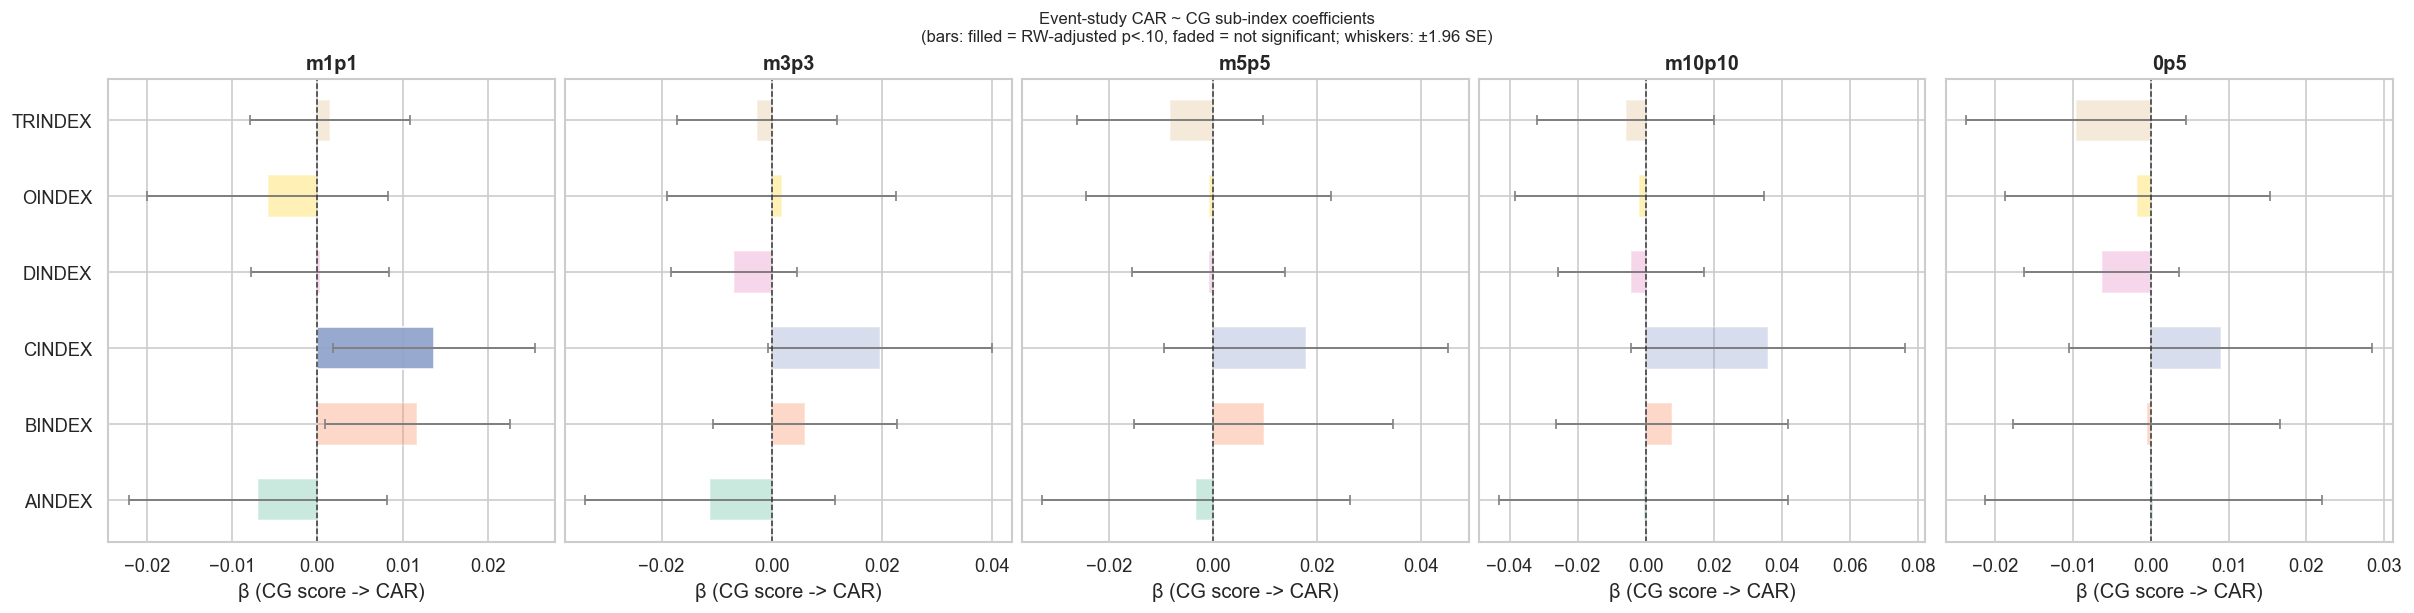

In [10]:
window_order = list(EVENT_WINDOWS.keys())
fig, axes = plt.subplots(1, len(window_order), figsize=(4 * len(window_order), 5),
                         sharey=True, constrained_layout=True)
colors = plt.cm.Set2(np.linspace(0, 0.8, len(CG_CATS)))
ypos = np.arange(len(CG_CATS))

for ax, w in zip(axes, window_order):
    sub = reg_df[reg_df['Window'] == w].set_index('Category').reindex(CG_CATS)
    for i, (cat, color) in enumerate(zip(CG_CATS, colors)):
        row = sub.loc[cat]
        if pd.isna(row['beta']):
            continue
        alpha_val = 0.9 if row['p_rw'] < 0.10 else 0.35
        ax.barh(i, row['beta'], xerr=row['se'] * 1.96, color=color, alpha=alpha_val,
                height=0.55, error_kw={'linewidth': 1.2, 'capsize': 3, 'ecolor': 'grey'})
    ax.axvline(0, color='#333', lw=0.9, ls='--')
    ax.set_title(w, fontweight='bold')
    ax.set_xlabel('β (CG score -> CAR)')
    ax.set_yticks(ypos)
    ax.set_yticklabels(CG_CATS)

fig.suptitle('Event-study CAR ~ CG sub-index coefficients\n'
             '(bars: filled = RW-adjusted p<.10, faded = not significant; whiskers: ±1.96 SE)',
             fontsize=10)
plt.show()

## 7 — Robustness: excluding overlapping filings

Repeats §6 excluding every event flagged `overlapping` in §2 (a second filing within ~20
trading days of an earlier one for the same firm). Same Romano-Wolf procedure, independently
re-run on the smaller sample — not just a subset of the primary bootstrap.

In [11]:
car_df_excl = car_df[~car_df['overlapping']].reset_index(drop=True)
print(f'Events after excluding overlaps: {len(car_df_excl):,} / {len(car_df):,}')

hyp_excl = build_hyp_data(car_df_excl)
t_excl, p_rw_excl = romano_wolf(hyp_excl)

excl_rows = []
for (cat, w), d in hyp_excl.items():
    beta, se, t = cluster_ols(d['y'], d['X'], d['cl'])
    p_raw = 2 * (1 - stats.norm.cdf(abs(t)))
    excl_rows.append({'Category': cat, 'Window': w, 'N': d['N'], 'beta': beta,
                      't': t, 'p_raw': p_raw, 'p_rw': p_rw_excl[(cat, w)]})
excl_df = pd.DataFrame(excl_rows)
excl_df['sig_rw'] = excl_df['p_rw'].apply(sig_stars)

compare = (reg_df[['Category','Window','N','beta','t','p_rw']]
           .merge(excl_df[['Category','Window','N','beta','t','p_rw']],
                  on=['Category','Window'], suffixes=('_all','_excl_overlap')))
print(f"\nPrimary (all events)     — survive p_rw<.10 : {(reg_df['p_rw'] < 0.10).sum()} / {len(reg_df)}")
print(f"Robustness (excl. overlap) — survive p_rw<.10 : {(excl_df['p_rw'] < 0.10).sum()} / {len(excl_df)}")
print()
print(compare.sort_values('p_rw_excl_overlap').round(4).to_string(index=False))

Events after excluding overlaps: 2,356 / 2,394



Primary (all events)     — survive p_rw<.10 : 1 / 30
Robustness (excl. overlap) — survive p_rw<.10 : 2 / 30

Category Window  N_all  beta_all   t_all  p_rw_all  N_excl_overlap  beta_excl_overlap  t_excl_overlap  p_rw_excl_overlap
  BINDEX   m1p1   2287    0.0117  2.1234    0.1355            2253             0.0128          2.2838             0.0945
  CINDEX   m1p1   2392    0.0136  2.2565    0.0980            2354             0.0140          2.2537             0.0945
  CINDEX   m3p3   2392    0.0196  1.8873    0.2590            2354             0.0204          1.9333             0.2350
  CINDEX m10p10   2392    0.0358  1.7419    0.3685            2354             0.0343          1.6508             0.4580
  DINDEX    0p5   2287   -0.0064 -1.2444    0.8115            2253            -0.0071         -1.3805             0.7240
 TRINDEX    0p5   2287   -0.0096 -1.3294    0.7590            2253            -0.0095         -1.3606             0.7275
  DINDEX   m3p3   2287   -0.0069 -1.1773   

## Summary and saved outputs

In [12]:
# Event-level CARs (primary sample)
car_out_cols = (['BSE Code', 'NSE Symbol', 'Q_FY', 'Filing_Date', 'overlapping', 'n_est_obs']
                + [f'CAR_{w}' for w in EVENT_WINDOWS] + CG_CATS)
car_df[car_out_cols].to_csv(PROC / 'event_study_car.csv', index=False)

# Cross-sectional regression results (primary + overlap-excluded robustness)
reg_df.to_csv(PROC / 'event_study_regressions_primary.csv', index=False)
excl_df.to_csv(PROC / 'event_study_regressions_excl_overlap.csv', index=False)
mean_car_df.to_csv(PROC / 'event_study_mean_car_tests.csv', index=False)

print('=' * 68)
print('  EVENT STUDY SUMMARY')
print('=' * 68)
print(f'\nEvents (primary, all filings)      : {len(car_df):,}  ({car_df["BSE Code"].nunique()} firms)')
print(f'Events (overlap-excluded robustness): {len(car_df_excl):,}')
print(f'Filing date range                  : {car_df["Filing_Date"].min().date()} -> {car_df["Filing_Date"].max().date()}')

print('\n[Mean CAR ≠ 0 — cross-sectional t-test / BMP]')
print(mean_car_df[['Window','N','Mean_CAR','t_stat','p_t','BMP_z','p_bmp']].round(4).to_string(index=False))

print('\n[Cross-sectional regression, primary — Romano-Wolf across 30 tests]')
print(f"  Survive raw p<.10  : {(reg_df['p_raw'] < 0.10).sum()} / {len(reg_df)}")
print(f"  Survive RW p<.10   : {(reg_df['p_rw'] < 0.10).sum()} / {len(reg_df)}")
if (reg_df['p_rw'] < 0.10).any():
    print(reg_df[reg_df['p_rw'] < 0.10][['Category','Window','beta','t','p_rw']].round(4).to_string(index=False))

print('\n[Overlap-excluded robustness]')
print(f"  Survive RW p<.10   : {(excl_df['p_rw'] < 0.10).sum()} / {len(excl_df)}")

print('\nSaved:')
for f in ['event_study_car.csv', 'event_study_regressions_primary.csv',
          'event_study_regressions_excl_overlap.csv', 'event_study_mean_car_tests.csv']:
    print(f'  -> data/processed/{f}')
print('=' * 68)

  EVENT STUDY SUMMARY

Events (primary, all filings)      : 2,394  (227 firms)
Events (overlap-excluded robustness): 2,356
Filing date range                  : 2023-07-06 -> 2026-03-10

[Mean CAR ≠ 0 — cross-sectional t-test / BMP]
Window    N  Mean_CAR  t_stat    p_t   BMP_z  p_bmp
  m1p1 2394   -0.0046 -5.4131 0.0000 -5.3808 0.0000
  m3p3 2394   -0.0088 -6.1329 0.0000 -6.2198 0.0000
  m5p5 2394   -0.0081 -4.3022 0.0000 -4.4196 0.0000
m10p10 2394   -0.0005 -0.1783 0.8585 -0.0968 0.9229
   0p5 2394   -0.0057 -4.3390 0.0000 -4.4744 0.0000

[Cross-sectional regression, primary — Romano-Wolf across 30 tests]
  Survive raw p<.10  : 4 / 30
  Survive RW p<.10   : 1 / 30
Category Window   beta      t  p_rw
  CINDEX   m1p1 0.0136 2.2565 0.098

[Overlap-excluded robustness]
  Survive RW p<.10   : 2 / 30

Saved:
  -> data/processed/event_study_car.csv
  -> data/processed/event_study_regressions_primary.csv
  -> data/processed/event_study_regressions_excl_overlap.csv
  -> data/processed/event_stu

## 8 — Corrected primary spec: DINDEX excluded

Same Phase-2 fix as `09_regression.ipynb` Section 10 — DINDEX's D2-D5 components fail LLM
scoring on 61-67% of observations (diagnosed in `diagnostics.py`), so it's dropped as
non-estimable. This notebook has no industry fixed effects anywhere (it's a per-event
cross-section, not a firm-industry panel), so Fix 2 (singleton-industry drop) doesn't apply
here — this section is DINDEX exclusion only, re-run on the same primary sample (`car_df`)
as §6, nothing else changed.

In [13]:
CG_CATS_PRIMARY = [c for c in CG_CATS if c != 'DINDEX']
print(f'CG_CATS_PRIMARY: {CG_CATS_PRIMARY}')

hyp_primary_5 = build_hyp_data(car_df, cats=CG_CATS_PRIMARY)
print(f'Hypotheses (sub-index x window): {len(hyp_primary_5)} / 25')

t_primary_5, p_rw_primary_5 = romano_wolf(hyp_primary_5)

reg_rows_5 = []
for (cat, w), d in hyp_primary_5.items():
    beta, se, t = cluster_ols(d['y'], d['X'], d['cl'])
    p_raw = 2 * (1 - stats.norm.cdf(abs(t)))
    reg_rows_5.append({'Category': cat, 'Window': w, 'N': d['N'], 'beta': beta, 'se': se,
                       't': t, 'p_raw': p_raw, 'p_rw': p_rw_primary_5[(cat, w)]})

reg_df_primary = pd.DataFrame(reg_rows_5)
reg_df_primary['sig_raw'] = reg_df_primary['p_raw'].apply(sig_stars)
reg_df_primary['sig_rw'] = reg_df_primary['p_rw'].apply(sig_stars)

print(f"\nSurvive p_raw<.10 : {(reg_df_primary['p_raw'] < 0.10).sum()} / {len(reg_df_primary)}")
print(f"Survive p_rw<.10  : {(reg_df_primary['p_rw'] < 0.10).sum()} / {len(reg_df_primary)}")
print()
print(reg_df_primary.sort_values('p_rw')[['Category','Window','N','beta','se','t','p_raw','sig_raw','p_rw','sig_rw']]
      .round(4).to_string(index=False))

CG_CATS_PRIMARY: ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']


Hypotheses (sub-index x window): 25 / 25



Survive p_raw<.10 : 4 / 25
Survive p_rw<.10  : 1 / 25

Category Window    N    beta     se       t  p_raw sig_raw   p_rw sig_rw
  CINDEX   m1p1 2392  0.0136 0.0060  2.2565 0.0240      ** 0.0800      *
  BINDEX   m1p1 2287  0.0117 0.0055  2.1234 0.0337      ** 0.1150       
  CINDEX   m3p3 2392  0.0196 0.0104  1.8873 0.0591       * 0.2150       
  CINDEX m10p10 2392  0.0358 0.0206  1.7419 0.0815       * 0.3135       
 TRINDEX    0p5 2287 -0.0096 0.0072 -1.3294 0.1837         0.6995       
  CINDEX   m5p5 2392  0.0179 0.0139  1.2828 0.1996         0.7300       
  AINDEX   m3p3 2287 -0.0112 0.0115 -0.9696 0.3322         0.9320       
  AINDEX   m1p1 2287 -0.0070 0.0077 -0.9038 0.3661         0.9510       
 TRINDEX   m5p5 2287 -0.0082 0.0091 -0.8980 0.3692         0.9510       
  CINDEX    0p5 2392  0.0089 0.0100  0.8973 0.3696         0.9510       
  OINDEX   m1p1 2287 -0.0058 0.0072 -0.8093 0.4183         0.9515       
  BINDEX   m5p5 2287  0.0097 0.0127  0.7676 0.4427         0.9590   

### 8.1 — Save outputs

Distinct filenames — `event_study_regressions_primary.csv` (30-test, 6-index family) is
not overwritten.

In [14]:
reg_df_primary.to_csv(PROC / 'event_study_regressions_primary_dindex_excluded.csv', index=False)
print('Saved -> data/processed/event_study_regressions_primary_dindex_excluded.csv')

print('=' * 68)
print('  SECTION 8 SUMMARY — DINDEX EXCLUDED')
print('=' * 68)
print(f'Family: {len(reg_df_primary)} tests (5 sub-indices x 5 windows), vs 30 in the original 6-index family')
print(f"Survive RW p<.10: {(reg_df_primary['p_rw'] < 0.10).sum()} / {len(reg_df_primary)}")
sig = reg_df_primary[reg_df_primary['p_rw'] < 0.10]
print(sig.round(4).to_string(index=False) if len(sig) else '(none)')
print('=' * 68)

Saved -> data/processed/event_study_regressions_primary_dindex_excluded.csv
  SECTION 8 SUMMARY — DINDEX EXCLUDED
Family: 25 tests (5 sub-indices x 5 windows), vs 30 in the original 6-index family
Survive RW p<.10: 1 / 25
Category Window    N   beta    se      t  p_raw  p_rw sig_raw sig_rw
  CINDEX   m1p1 2392 0.0136 0.006 2.2565  0.024  0.08      **      *
